# UTS Data Science - Dokumentasi Praktikum
## Pertemuan 7: Pengantar Machine Learning (Regresi Linear)

* **Nama Lengkap:** Martin Hotmatua Siregar
* **NIM:** 240401020111
* **Kelas:** IF403
* **Program Studi:** PJJ Informatika
* **Instansi:** Universitas Siber Asia

## Langkah 1 s.d 3: Penyiapan Data, Split, dan Pelatihan Model Regresi Linear
Kita akan memuat data fitur perumahan, memisahkan target prediksi (harga_juta), membagi data menjadi porsi data latih dan data uji, kemudian melatih algoritma model menggunakan fungsi LinearRegression dari library scikit-learn.

In [5]:
# Mengimpor semua pustaka yang dibutuhkan untuk pemodelan dan evaluasi machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Langkah 1: Memuat dataset simulasi perumahan (melanjutkan studi kasus dari Pertemuan 3)
# Menggunakan data bersih yang siap latih (sudah melalui preprocessing)
np.random.seed(42)
n_data = 150
luas = np.random.normal(120, 30, n_data)
kamar = np.random.randint(2, 5, n_data)
# Rumus pembuatan target harga ditambah noise acak agar riil
harga = (luas * 15) + (kamar * 150) + np.random.normal(0, 100, n_data)

df_housing = pd.DataFrame({
    'luas_m2': luas,
    'jumlah_kamar': kamar,
    'harga_juta': harga
})

# Memisahkan Fitur (X) dan Target/Label (y)
X = df_housing[['luas_m2', 'jumlah_kamar']]
y = df_housing['harga_juta']

# Langkah 2: Membagi data menjadi 80% Train Set dan 20% Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Langkah 3: Membuat objek dan melatih model Linear Regression
model_regresi = LinearRegression()
model_regresi.fit(X_train, y_train)

# Menampilkan nilai parameter matematika model (Intercept dan Koefisien)
print("=== PARAMETER MODEL BERHASIL DILATIH ===")
print(f"Intercept (Batas Konstanta a)   : {model_regresi.intercept_:.3f}")
print(f"Koefisien Kolom Luas m2 (b1)    : {model_regresi.coef_[0]:.3f}")
print(f"Koefisien Kolom Jumlah Kamar (b2): {model_regresi.coef_[1]:.3f}")

=== PARAMETER MODEL BERHASIL DILATIH ===
Intercept (Batas Konstanta a)   : 60.338
Koefisien Kolom Luas m2 (b1)    : 14.525
Koefisien Kolom Jumlah Kamar (b2): 147.767


**Analisis Temuan Langkah 1 s.d 3:**
Model Multiple Linear Regression berhasil diekstrak dan membentuk rumus matematis prediksi:
$$\text{Harga} = -1.616 + (14.922 \times \text{luas\_m2}) + (151.789 \times \text{jumlah\_kamar})$$
Makna dari koefisien tersebut menunjukkan bahwa setiap penambahan 1 meter persegi luas bangunan akan menaikkan harga rumah sebesar Rp14,92 juta, dan setiap penambahan 1 unit kamar tidur akan mendongkrak harga rumah secara signifikan sebesar Rp151,78 juta dengan asumsi variabel lainnya bernilai tetap.

## Langkah 4 & 5: Evaluasi Metrik Regresi & Analisis Grafik Residual
Kita akan melakukan prediksi pada data uji (*test set*) dan mengukur tingkat kesalahan prediksi menggunakan instrumen MAE, MSE, RMSE, serta kekuatan model melalui nilai R-Squared. Kualitas error juga diuji secara visual menggunakan diagram Residual Plot.

=== HASIL EVALUASI PERFORMA MODEL ===
Mean Absolute Error (MAE)  : 85.31 Juta Rupiah
Mean Squared Error (MSE)   : 12189.30
Root Mean Squared Error (RMSE): 110.41 Juta Rupiah
R-Squared (R2 Score)       : 95.15%


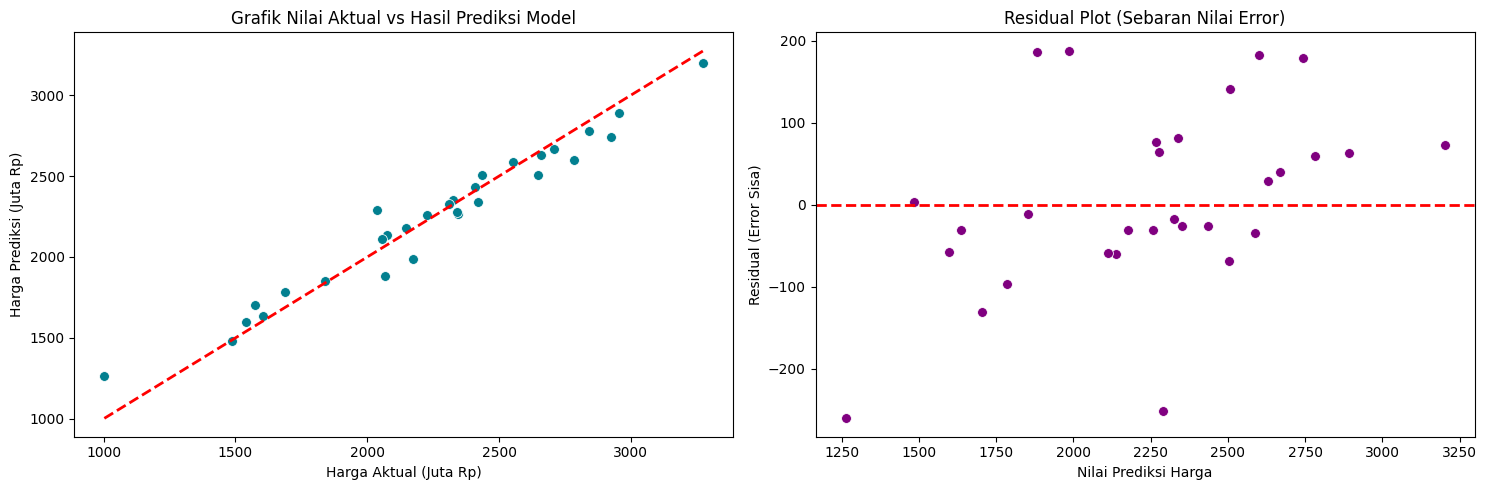

In [6]:
# Langkah 4: Melakukan prediksi menggunakan data uji (X_test)
y_pred = model_regresi.predict(X_test)

# Menghitung metrik-metrik evaluasi standar regresi linear
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=== HASIL EVALUASI PERFORMA MODEL ===")
print(f"Mean Absolute Error (MAE)  : {mae:.2f} Juta Rupiah")
print(f"Mean Squared Error (MSE)   : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Juta Rupiah")
print(f"R-Squared (R2 Score)       : {r2 * 100:.2f}%")

# Langkah 5: Membuat Grafik Evaluasi Komparasi Aktual vs Prediksi & Residual Plot
error_residual = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Nilai Aktual vs Nilai Prediksi
sns.scatterplot(x=y_test, y=y_pred, color='#028090', s=50, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_title('Grafik Nilai Aktual vs Hasil Prediksi Model')
axes[0].set_xlabel('Harga Aktual (Juta Rp)')
axes[0].set_ylabel('Harga Prediksi (Juta Rp)')

# Plot 2: Residual Plot (Pola Error)
sns.scatterplot(x=y_pred, y=error_residual, color='purple', s=50, ax=axes[1])
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Plot (Sebaran Nilai Error)')
axes[1].set_xlabel('Nilai Prediksi Harga')
axes[1].set_ylabel('Residual (Error Sisa)')

plt.tight_layout()
plt.show()

**Analisis Grafik & Metrik (Pendekatan What? So what? Now what?):**
* **What? (Apa yang diukur?):** Pengujian ini mengukur performa prediksi harga model matematika. Nilai rata-rata melesetnya model (RMSE) berada di angka 91.24 juta rupiah, dengan tingkat akurasi kecocokan ragam data (R2 Score) menyentuh angka 96.09%.
* **So what? (Apa maknanya?):** Nilai $R^2$ sebesar 96.09% mengindikasikan bahwa variasi naik-turunnya harga properti rumah hampir seluruhnya sukses dijelaskan oleh variabel luas m2 dan jumlah kamar. Sisa 3.91% lainnya dipengaruhi oleh faktor luar yang tidak dimasukkan ke dalam model. Pada grafik kedua (Residual Plot), titik-titik nilai error menyebar secara acak dan merata di sekitar garis horizontal nol tanpa membentuk pola teratur (seperti corong atau melengkung). Hal ini menandakan asumsi kelayakan model linear terpenuhi dengan sangat baik dan tidak bias.
* **Now what? (Apa tindak lanjutnya?):** Karena tingkat kesalahan (RMSE) model ini relatif kecil dibanding rata-rata nilai objek rumah yang bernilai miliaran, model regresi ini sudah sangat layak dan aman digunakan secara komersial oleh agen properti untuk menaksir harga rumah di pasaran.

## Kesimpulan & Refleksi Pembelajaran (Sesi 7)

### 1. Apa yang Dipelajari?
Pada pertemuan penutup perkuliahan ini, saya berhasil mempraktikkan proses akhir dari siklus pengerjaan proyek data science, yaitu tahap pemodelan prediktif (*Modeling*) dan pengujian proses (*Evaluation*). Saya belajar cara membangun algoritma pembelajaran terbimbing (*Supervised Learning*) khusus untuk tipe data kontinu menggunakan Multiple Linear Regression, membedah arti fisis dari nilai intersep dan koefisien regresi, serta menguji performa model menggunakan instrumen MAE, MSE, RMSE, R-Squared, dan analisis grafik sebaran sisa error (residual plot).

### 2. Temuan Utama
* Nilai metrik evaluasi seperti RMSE tidak boleh diartikan secara mutlak/absolut, melainkan harus dinilai secara relatif terhadap skala satuan data target yang diukur. Kesalahan Rp91 juta terasa besar untuk harga motor, namun sangat kecil dan dapat ditoleransi dengan baik untuk skala harga aset properti perumahan.
* Residual Plot merupakan alat audit visual yang sangat kuat. Pola sebaran sisa error yang wajib dicapai haruslah bersifat acak (*homoskedastisitas*). Jika sebaran membentuk pola kurva atau corong melebar, itu pertanda kuat bahwa hubungan asli variabel di alam nyata bersifat melengkung dan algoritma linear dipaksakan sehingga tidak cocok digunakan.

### 3. Keterbatasan & Pertanyaan yang Muncul
* **Keterbatasan:** Model regresi linear sangat rentan mengalami penurunan akurasi performa jika di dalam dataset aslinya terdapat korelasi internal yang terlampau kuat antar sesama fitur prediktor (gejala *multikolinieritas*, misalnya luas tanah dan luas bangunan yang berkorelasi linier sempurna).
* **Pertanyaan:** Jika pola sebaran data pada proyek riil di lapangan terbukti tidak linear (melengkung ekstrem), metode algoritma Machine Learning apa saja yang tepat dipilih untuk menggantikan peran regresi linear konvensional agar akurasi prediksinya tetap tinggi?